## Simulação

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.simulacoes import simular_PID, simular_step_test

from utils.plots import plot_results

## configurações

In [2]:

tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


## Controlador usando IMC

Temos 
* saída controlada: (X)
* variável manipulada: (D)
* perturbação futura: (S_f)

Em que, 
$$
G_{X,D}(s)=
\frac{-0.30667s-0.10733}{s^2+0.695s+0.12075}
$$
ou, fatorando:

$$
G_{X,D}(s)=
\frac{-0.30667(s+0.35)}{(s+0.345)(s+0.35)}
$$
Após o cancelamento aproximado:

$$
G_{X,D}(s)\approx
\frac{-0.30667}{s+0.345}
$$

Então, **não aparece termo de atraso** do tipo:

$$
e^{-\theta s}
$$

Assim, escolhendo $$(\frac{Y}{Y_{sp}})_d = \frac{1}{\tau_c s + 1}$$

Para a fórmula geral do Direct Synthesis:

$$
G_c=\frac{1}{\tilde G}
\frac{(Y/Y_{sp})_d}{1-(Y/Y_{sp})_d}
$$

Então,

$$
G_c=\frac1{\tilde G}
\frac1{\tau_c s}
$$


Escrevendo na forma padrão:

$$
G_{X,D}(s)=\frac{K}{\tau s+1}
$$

tenho

$$
K=\frac{-0.30667}{0.345}=-0.889
$$

e

$$
\tau=\frac1{0.345}=2.90 \ h
$$

Então:

$$
\tilde G(s)=\frac{-0.889}{2.90s+1}
$$

substituindo no que obteve-se de Direct Synthesis:

$$
G_c(s)=\frac1{\tilde G(s)}
\frac1{\tau_c s}
$$

$$
= \frac{2.90s+1}{-0.889}
\frac1{\tau_c s}
$$

$$
= -\frac1{0.889\tau_c}
\frac{2.90s+1}{s}
$$

que é semelhante a [forma PI](https://electronicscoach.com/proportional-integral-controller.html):

$$
G_{PI}(s)=K_c\frac{\tau_I s+1}{\tau_I s}
$$


Daí sai direto:

$$
\tau_I = 2.90 \ h
$$

e

$$
K_c=-\frac{2.90}{0.889\tau_c}
$$




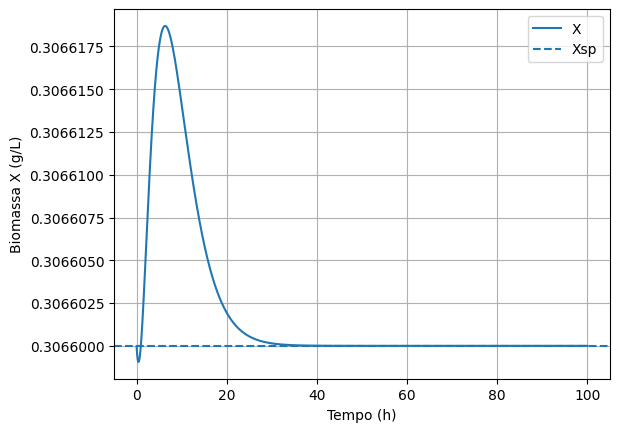

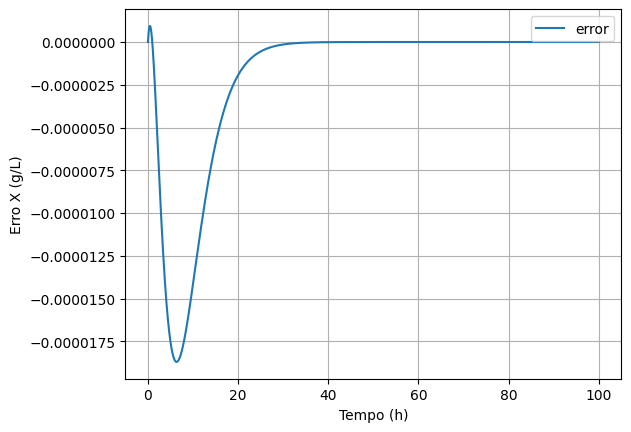

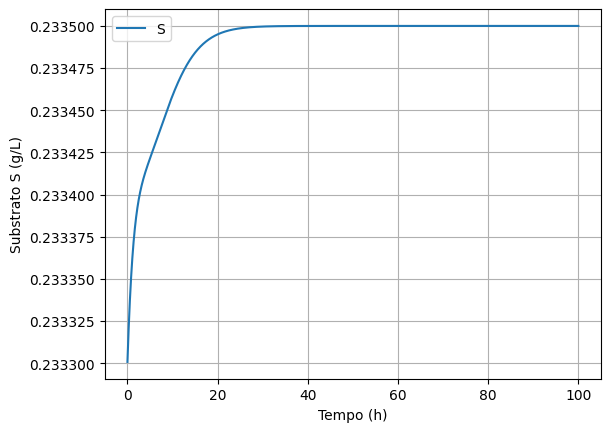

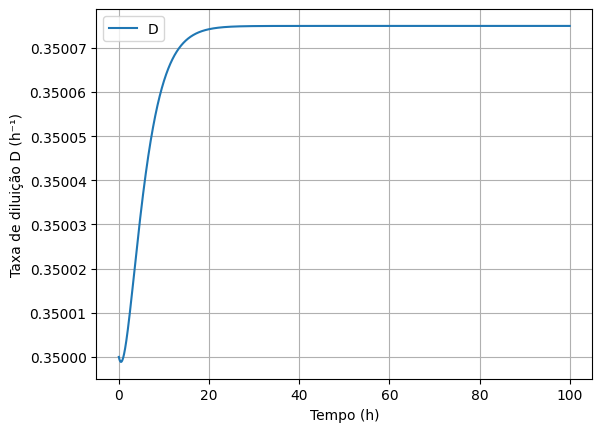

0.96


In [3]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
t1, X1, S1, D1, IAE_imc, ISE_imc, erro = simular_PID(Kc=Kc, Ti=Ti, Xsp=Xsp, D0=D0, states=states, tempo_final=tf)
c = 0
for i in erro:
    if i < 0:
        print(t1[c])
        break
    c+=1
# print(erro)

## controlador usando um método de sintonia online - Step Test Method

Inicialmente o processo já está em regime permanente

Em que
$$
D=0.35,\quad S_f=1.0
$$

e inicia em:

$$
X=0.3066,\quad S=0.2333
$$


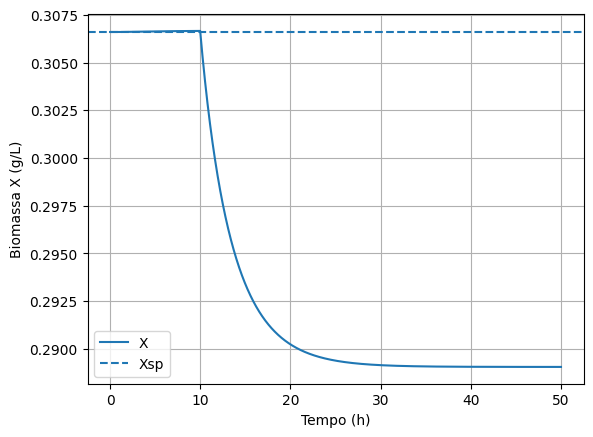

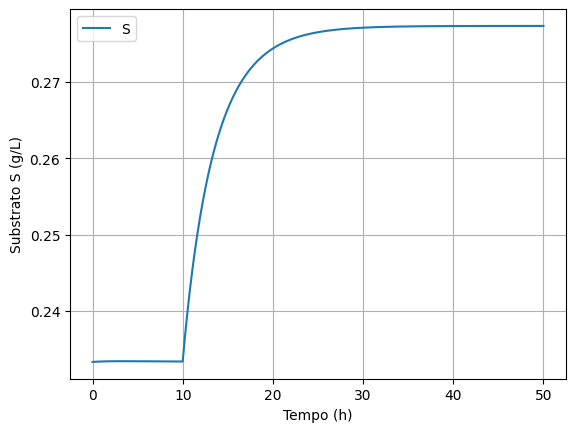

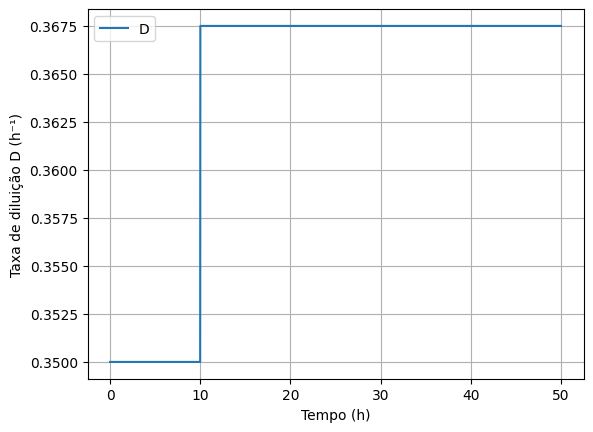

In [4]:
# entrada manipulada fixada em D0 - sem PID
# Aplicando  5% na saída do controlador em t = 10 h.
step_time = 10
t2, X2, S2, D2 = simular_step_test(D0=0.35, step_percent=0.05, step_time=step_time, states=np.array([0.3066, 0.2333]), tempo_final=50, dt=0.01)
plot_results(t2, X2, S2, D2, Xsp=Xsp)

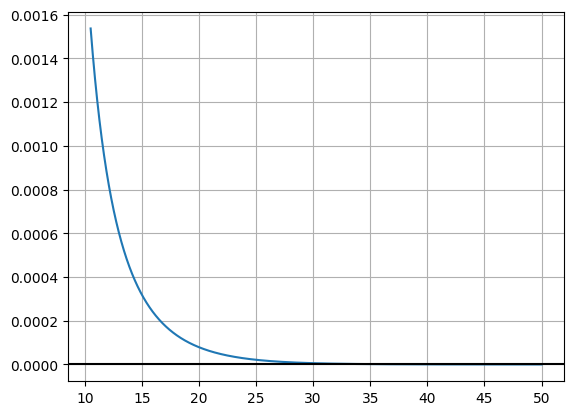

In [5]:
# verificando inflexão
dX = np.gradient(X2, t2)
d2X = np.gradient(dX, t2)
mask = t2 > 10.5

plt.figure()
plt.plot(t2[mask], d2X[mask])
plt.axhline(0, color='k')
plt.grid()
plt.show()

Após descontinuidade (t = 10), a segunda derivada não muda de sinal, não tendo ponto de inflexão -> método da tangente no ponto de inflexão talvez não seja aplicável.


## RELAY

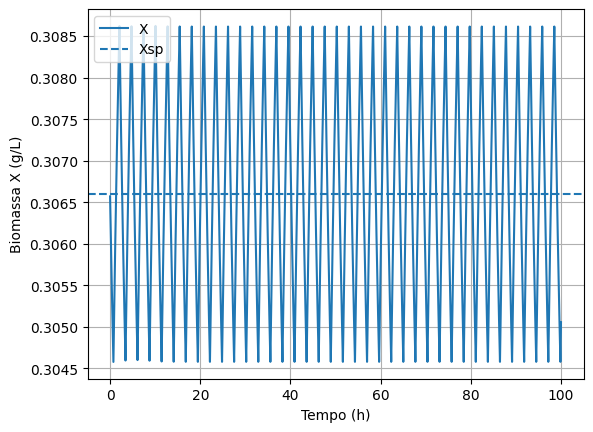

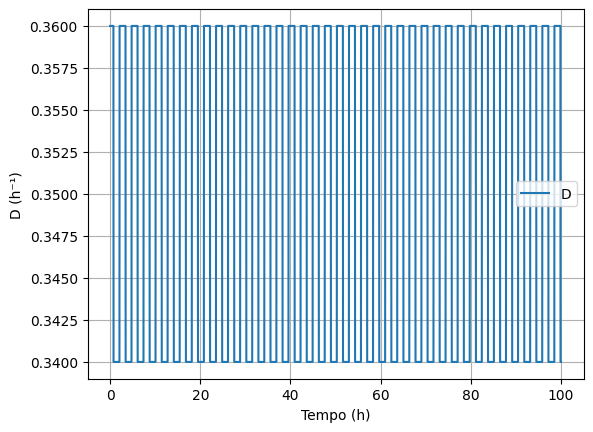

In [6]:
from utils.simulacoes import simular_relay_autotuning

t_relay, X_relay, S_relay, D_relay = simular_relay_autotuning(
    Xsp=0.3066,
    D0=0.35,
    d=0.01,
    dead_zone=0.002,
    states=np.array([0.3066, 0.2333]),
    tempo_final=100,
    dt=0.01
)

plt.figure()
plt.plot(t_relay, X_relay, label="X")
plt.axhline(0.3066, linestyle="--", label="Xsp")
plt.xlabel("Tempo (h)")
plt.ylabel("Biomassa X (g/L)")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(t_relay, D_relay, label="D")
plt.xlabel("Tempo (h)")
plt.ylabel("D (h⁻¹)")
plt.legend()
plt.grid()
plt.show()

Kc = -2.840
Ti = 2.232 h
Td = 0.000 h


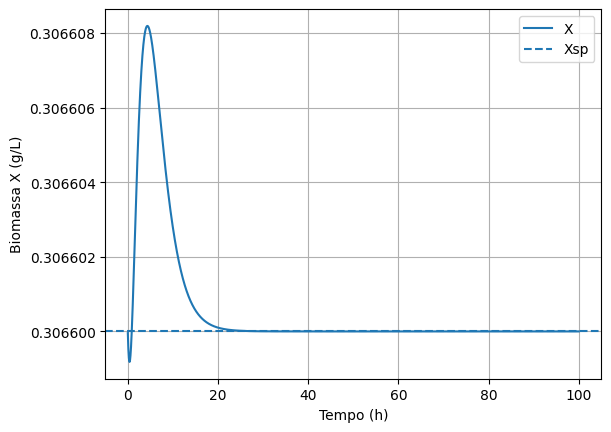

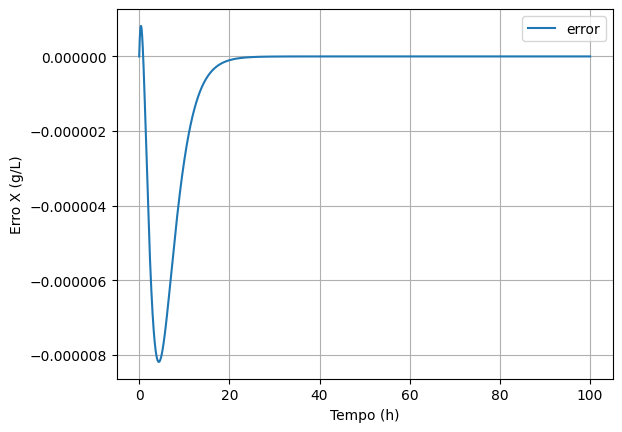

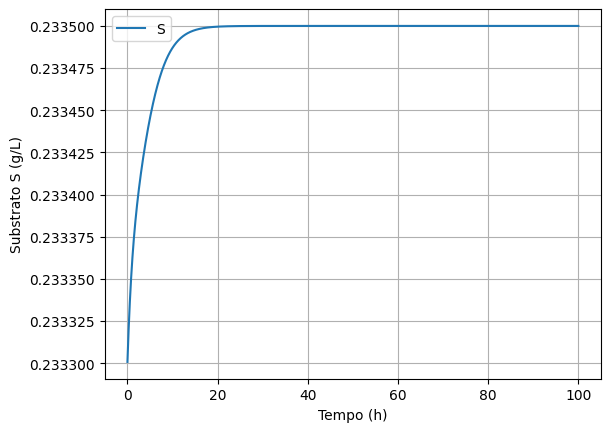

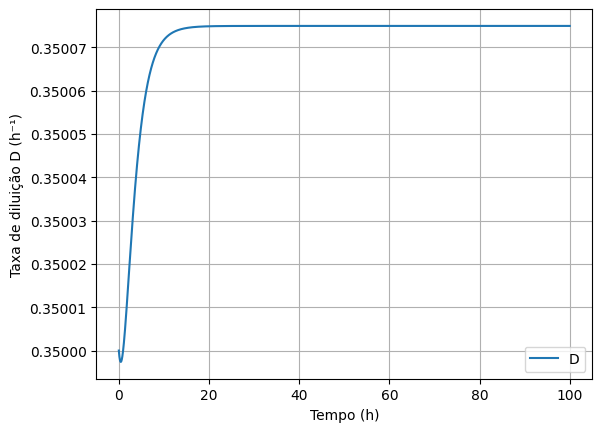

In [7]:
# parametros
from utils.simulacoes import estimar_parametros_relay
a, Pu, Kcu, Kc_relay, Ti_relay, Td_relay = estimar_parametros_relay(
    t_relay,
    X_relay,
    d=0.01,
    tempo_descartar=0
)

# print(f"a = {a:.6f}")
# print(f"Pu = {Pu:.3f} h")
# print(f"Kcu = {Kcu:.3f}")
print(f"Kc = {-Kc_relay:.3f}")
print(f"Ti = {Ti_relay:.3f} h")
print(f"Td = {Td_relay:.3f} h")

td, Xd, Sd, Dd, IAE_relay, ISE_relay,erro_relay = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=Xsp, D0=D0, states=states, tempo_final=tf)


## metricas

In [8]:
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC"],
    "IAE": [IAE_relay, IAE_imc],
    "ISE": [ISE_relay, ISE_imc]
})

display(resultados)

,Controlador,IAE,ISE
0,Relay,0.000060,3.347167e-10
1,IMC,0.000201,2.600666e-09


## com pertubação

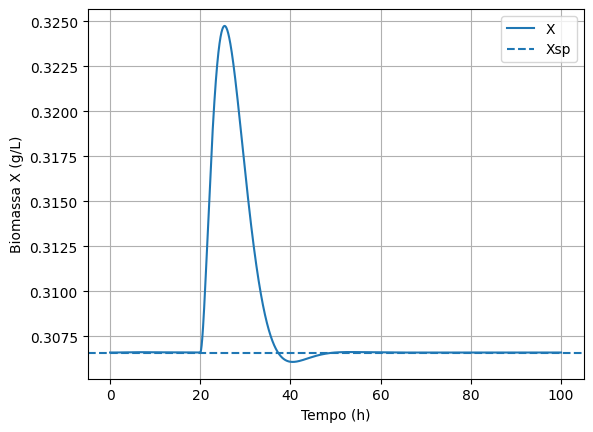

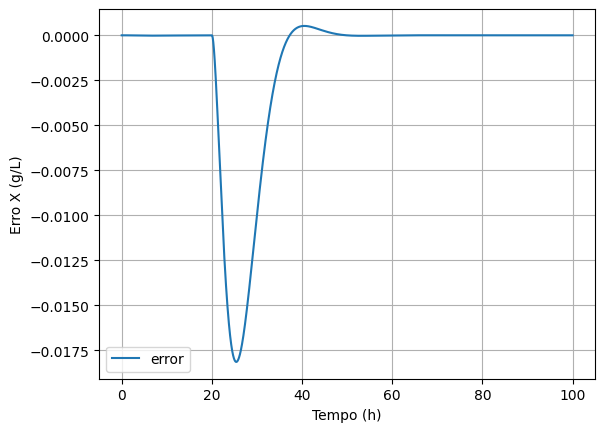

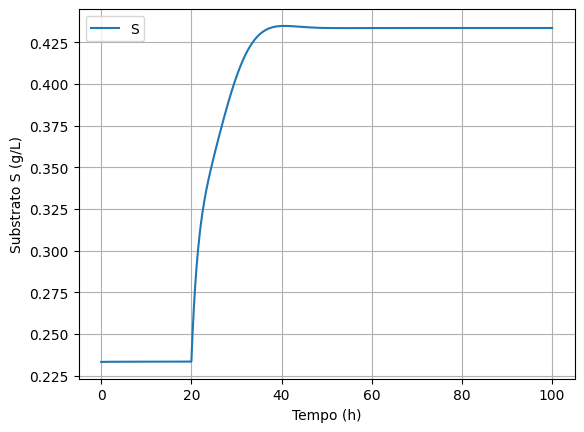

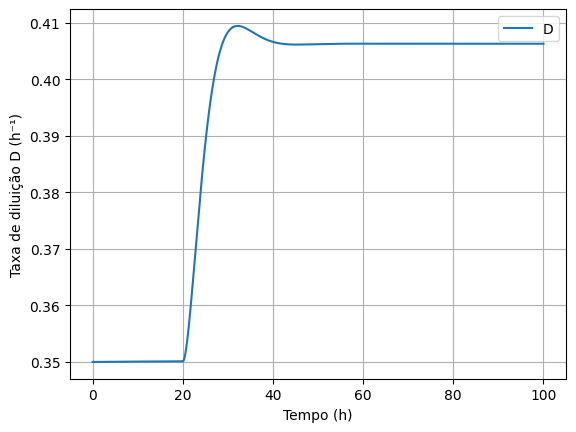

ValueError: too many values to unpack (expected 6)

In [9]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
t1, X1, S1, D1, IAE_imc_pertubado, ISE_imc_pertubado  = simular_PID(Kc=Kc, Ti=Ti, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=True, t_pert=20, Sf_pert = 1.2)


In [ ]:
td, Xd, Sd, Dd, IAE_relay_pertubado, ISE_relay_pertubado = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=Xsp, D0=D0, states=states, tempo_final=tf, pert=True, t_pert=20, Sf_pert=1.2)

In [ ]:
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC"],
    "IAE": [IAE_relay_pertubado, IAE_imc_pertubado],
    "ISE": [ISE_relay_pertubado, ISE_imc_pertubado]
})

display(resultados)

In [ ]:
# simulacao com Tc = 3h
Tc = 3  # h 
Kc = -2.9/(0.889*Tc)
Ti = 2.9 # h 
t1, X1, S1, D1, IAE_imc_X, ISE_imc_X  = simular_PID(Kc=Kc, Ti=Ti, Xsp=0.35, D0=D0, states=states, tempo_final=tf, pert=False, t_pert=20, Sf_pert = 1.2)

td, Xd, Sd, Dd, IAE_relay_X, ISE_relay_X = simular_PID(Kc=-Kc_relay, Ti=Ti_relay, Xsp=0.35, D0=D0, states=states, tempo_final=tf, pert=False, t_pert=20, Sf_pert=1.2)
resultados = pd.DataFrame({
    "Controlador": ["Relay", "IMC"],
    "IAE": [IAE_relay_X, IAE_imc_X],
    "ISE": [ISE_relay_X, ISE_imc_X]
})

display(resultados)

In [ ]:

# vou usar método dos 63,2% e encontrar o instante em que a curva cruza esse valor:
# $$
# X_\tau=X_0 + 0.632(X_f-X_0)
# $$

# X0 = X2[0]
# Xf = X2[-1]

# Xtau = X0 + 0.632*(Xf - X0)
# print(f"Xtau = {Xtau:.3f}")
# idx = np.argmin(np.abs(np.array(X2) - Xtau))

# tau = t2[idx] - step_time
# print(f"tau = {tau:.3f}")

# plt.figure()
# plt.plot(t2, X2)
# plt.axhline(Xtau, color='r', linestyle='--')
# plt.axvline(step_time + tau, color='g', linestyle='--')
# plt.grid()
# plt.show()

In [ ]:
# %load_ext jupyter_tikz

In [ ]:
# from utils.apresentarDiagrama import tikz
# from diagramas.pid import diagrama_pid

# tikz(diagrama_pid)